# PER DQN Resume Analysis

This notebook compares the two PER-DQN runs:
- `per_dqn_20260411-115233`: initial `0 -> 100k`
- `per_dqn_20260411-191026`: resumed `100k -> 200k`

It shows per-run summaries and an approximate concatenated view of the full training trajectory.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

BASE_DIR = Path('../checkpoints')
RUN_ORDER = [
    'per_dqn_20260411-115233',
    'per_dqn_20260411-191026',
]

for run_name in RUN_ORDER:
    run_dir = BASE_DIR / run_name
    assert run_dir.exists(), f'Missing run directory: {run_dir}'


def load_run(run_name):
    run_dir = BASE_DIR / run_name
    rewards = np.load(run_dir / 'episode_rewards.npy')
    lengths = np.load(run_dir / 'ep_lengths.npy')
    losses = np.load(run_dir / 'losses.npy')
    checkpoints = sorted(run_dir.glob('*per_dqn_*.pt'))
    final_ckpts = sorted(run_dir.glob('*final.pt'))
    final_ckpt = final_ckpts[-1] if final_ckpts else checkpoints[-1]
    ckpt = torch.load(final_ckpt, map_location='cpu')
    return {
        'name': run_name,
        'dir': run_dir,
        'rewards': rewards,
        'lengths': lengths,
        'losses': losses,
        'checkpoints': checkpoints,
        'final_ckpt': final_ckpt,
        'final_step': int(ckpt['global_step']),
    }


runs = [load_run(run_name) for run_name in RUN_ORDER]

for run in runs:
    print(run['name'])
    print('  dir           :', run['dir'])
    print('  episodes      :', len(run['rewards']))
    print('  length_count  :', len(run['lengths']))
    print('  loss_count    :', len(run['losses']))
    print('  checkpoints   :', len(run['checkpoints']))
    print('  final_ckpt    :', run['final_ckpt'].name)
    print('  final_step    :', run['final_step'])
    print()

combined = {
    'rewards': np.concatenate([run['rewards'] for run in runs]),
    'lengths': np.concatenate([run['lengths'] for run in runs]),
    'losses': np.concatenate([run['losses'] for run in runs]),
}

print('combined episodes   :', len(combined['rewards']))
print('combined lengths    :', len(combined['lengths']))
print('combined losses     :', len(combined['losses']))
print('combined final step :', runs[-1]['final_step'])

per_dqn_20260411-115233
  dir           : ..\checkpoints\per_dqn_20260411-115233
  episodes      : 9756
  length_count  : 9756
  loss_count    : 99800
  checkpoints   : 11
  final_ckpt    : 20260411-170818_per_dqn_final.pt
  final_step    : 99999

per_dqn_20260411-191026
  dir           : ..\checkpoints\per_dqn_20260411-191026
  episodes      : 7512
  length_count  : 7512
  loss_count    : 99986
  checkpoints   : 11
  final_ckpt    : 20260412-021940_per_dqn_final.pt
  final_step    : 199999

combined episodes   : 17268
combined lengths    : 17268
combined losses     : 199786
combined final step : 199999


In [2]:
def summarize_array(arr, tail):
    arr = np.asarray(arr)
    if len(arr) == 0:
        return {
            'count': 0,
            'first_mean': None,
            'last_mean': None,
            'last_std': None,
            'min': None,
            'max': None,
            'last': None,
        }
    first_slice = arr[: min(20, len(arr))]
    last_slice = arr[-min(tail, len(arr)):]
    return {
        'count': int(len(arr)),
        'first_mean': float(np.mean(first_slice)),
        'last_mean': float(np.mean(last_slice)),
        'last_std': float(np.std(last_slice)),
        'min': float(np.min(arr)),
        'max': float(np.max(arr)),
        'last': float(arr[-1]),
    }


def print_run_summary(label, rewards, lengths, losses):
    reward_stats = summarize_array(rewards, tail=20)
    length_stats = summarize_array(lengths, tail=20)
    loss_stats = summarize_array(losses, tail=100)
    print(label)
    print('  rewards')
    print('    mean first 20 :', reward_stats['first_mean'])
    print('    mean last 20  :', reward_stats['last_mean'])
    print('    std  last 20  :', reward_stats['last_std'])
    print('    min / max     :', reward_stats['min'], '/', reward_stats['max'])
    print('    last value    :', reward_stats['last'])
    print('  lengths')
    print('    mean first 20 :', length_stats['first_mean'])
    print('    mean last 20  :', length_stats['last_mean'])
    print('    std  last 20  :', length_stats['last_std'])
    print('    min / max     :', length_stats['min'], '/', length_stats['max'])
    print('    last value    :', length_stats['last'])
    print('  losses')
    print('    mean first 20 :', loss_stats['first_mean'])
    print('    mean last 100 :', loss_stats['last_mean'])
    print('    std  last 100 :', loss_stats['last_std'])
    print('    min / max     :', loss_stats['min'], '/', loss_stats['max'])
    print('    last value    :', loss_stats['last'])
    print()


for run in runs:
    print_run_summary(run['name'], run['rewards'], run['lengths'], run['losses'])

print_run_summary('combined_0_to_200k', combined['rewards'], combined['lengths'], combined['losses'])

per_dqn_20260411-115233
  rewards
    mean first 20 : 11.6761585354805
    mean last 20  : 23.0080765247345
    std  last 20  : 3.8302171450558675
    min / max     : 0.7989178895950317 / 29.35133171081543
    last value    : 24.85811424255371
  lengths
    mean first 20 : 16.65
    mean last 20  : 29.05
    std  last 20  : 4.652687395473717
    min / max     : 3.0 / 31.0
    last value    : 31.0
  losses
    mean first 20 : 0.2408887374214828
    mean last 100 : 0.12178747666068375
    std  last 100 : 0.08933013393048479
    min / max     : 0.004121076315641403 / 13.777900695800781
    last value    : 0.08039385080337524

per_dqn_20260411-191026
  rewards
    mean first 20 : 20.635196924209595
    mean last 20  : 20.943655586242677
    std  last 20  : 8.062236172899622
    min / max     : 0.9660165309906006 / 29.95901107788086
    last value    : 29.15011215209961
  lengths
    mean first 20 : 27.1
    mean last 20  : 23.8
    std  last 20  : 8.506468127254694
    min / max     : 3.0 

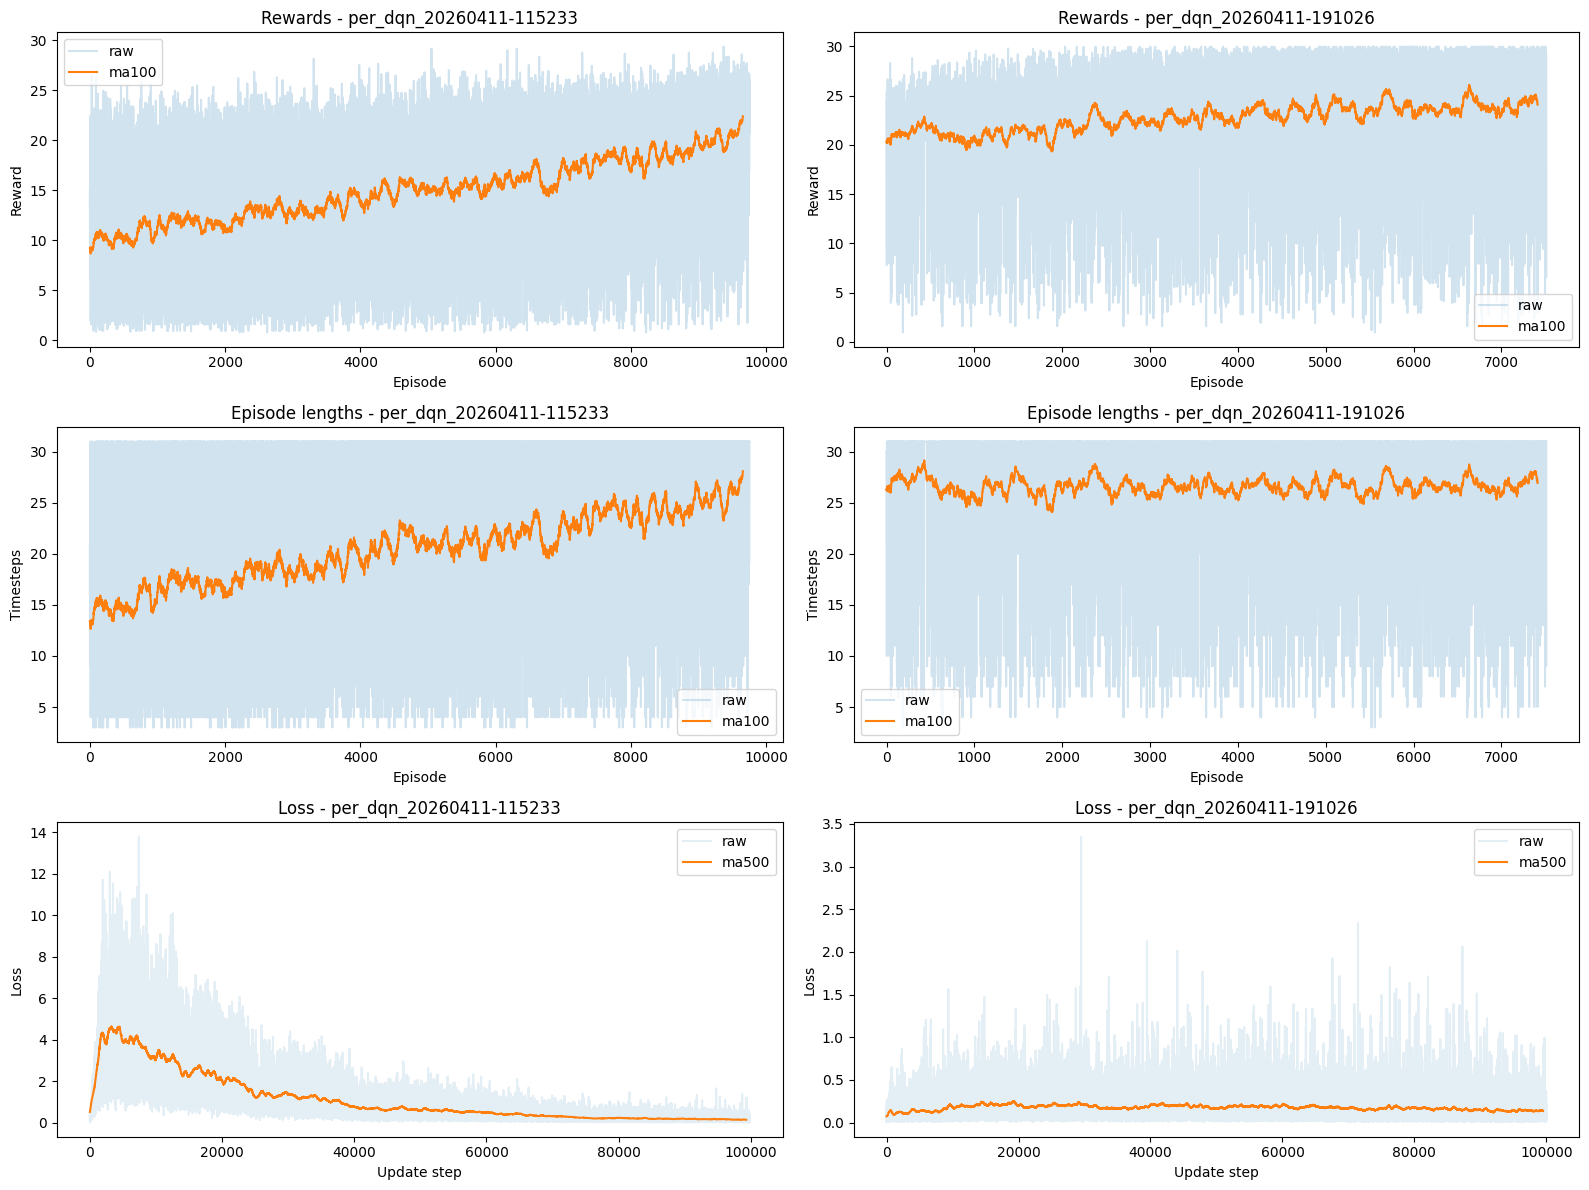

In [3]:
def moving_average(arr, window):
    arr = np.asarray(arr, dtype=np.float64)
    if len(arr) == 0:
        return arr
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='valid')


fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for col, run in enumerate(runs):
    rewards = run['rewards']
    lengths = run['lengths']
    losses = run['losses']
    axes[0, col].plot(rewards, alpha=0.2, label='raw')
    axes[0, col].plot(moving_average(rewards, 100), label='ma100')
    axes[0, col].set_title(f"Rewards - {run['name']}")
    axes[0, col].set_xlabel('Episode')
    axes[0, col].set_ylabel('Reward')
    axes[0, col].legend()

    axes[1, col].plot(lengths, alpha=0.2, label='raw')
    axes[1, col].plot(moving_average(lengths, 100), label='ma100')
    axes[1, col].set_title(f"Episode lengths - {run['name']}")
    axes[1, col].set_xlabel('Episode')
    axes[1, col].set_ylabel('Timesteps')
    axes[1, col].legend()

    axes[2, col].plot(losses, alpha=0.12, label='raw')
    axes[2, col].plot(moving_average(losses, 500), label='ma500')
    axes[2, col].set_title(f"Loss - {run['name']}")
    axes[2, col].set_xlabel('Update step')
    axes[2, col].set_ylabel('Loss')
    axes[2, col].legend()

plt.tight_layout()

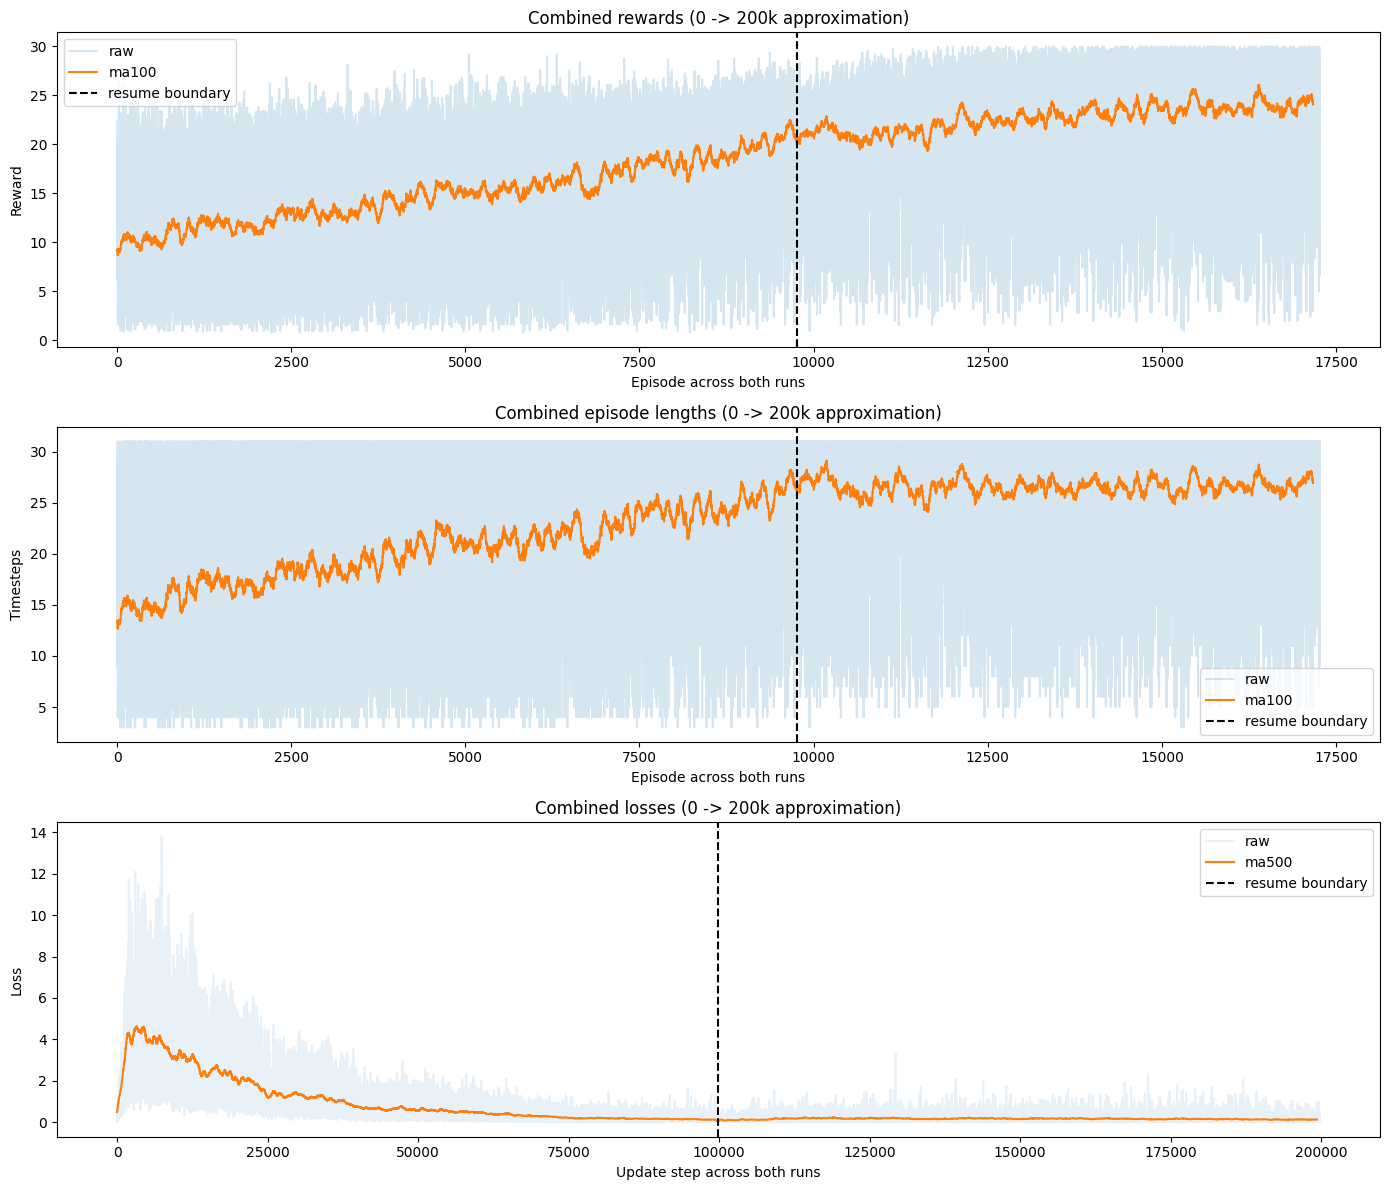

In [4]:
first_reward_len = len(runs[0]['rewards'])
first_length_len = len(runs[0]['lengths'])
first_loss_len = len(runs[0]['losses'])

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(combined['rewards'], alpha=0.18, label='raw')
axes[0].plot(moving_average(combined['rewards'], 100), label='ma100')
axes[0].axvline(first_reward_len, color='black', linestyle='--', label='resume boundary')
axes[0].set_title('Combined rewards (0 -> 200k approximation)')
axes[0].set_xlabel('Episode across both runs')
axes[0].set_ylabel('Reward')
axes[0].legend()

axes[1].plot(combined['lengths'], alpha=0.18, label='raw')
axes[1].plot(moving_average(combined['lengths'], 100), label='ma100')
axes[1].axvline(first_length_len, color='black', linestyle='--', label='resume boundary')
axes[1].set_title('Combined episode lengths (0 -> 200k approximation)')
axes[1].set_xlabel('Episode across both runs')
axes[1].set_ylabel('Timesteps')
axes[1].legend()

axes[2].plot(combined['losses'], alpha=0.10, label='raw')
axes[2].plot(moving_average(combined['losses'], 500), label='ma500')
axes[2].axvline(first_loss_len, color='black', linestyle='--', label='resume boundary')
axes[2].set_title('Combined losses (0 -> 200k approximation)')
axes[2].set_xlabel('Update step across both runs')
axes[2].set_ylabel('Loss')
axes[2].legend()

plt.tight_layout()

In [5]:
def print_chunks(label, rewards, lengths, chunk_size=100):
    print(label)
    for start in range(0, len(rewards), chunk_size):
        r = rewards[start:start + chunk_size]
        l = lengths[start:start + chunk_size]
        if len(r) == 0:
            continue
        print(
            f"  chunk {start:05d}-{start + len(r) - 1:05d}: "
            f"reward_mean={float(np.mean(r)):.3f}, "
            f"reward_std={float(np.std(r)):.3f}, "
            f"len_mean={float(np.mean(l)):.3f}"
        )
    print()


for run in runs:
    print_chunks(run['name'], run['rewards'], run['lengths'])

print_chunks('combined_0_to_200k', combined['rewards'], combined['lengths'])

per_dqn_20260411-115233
  chunk 00000-00099: reward_mean=9.227, reward_std=6.639, len_mean=13.400
  chunk 00100-00199: reward_mean=10.739, reward_std=7.051, len_mean=15.510
  chunk 00200-00299: reward_mean=10.027, reward_std=6.640, len_mean=14.500
  chunk 00300-00399: reward_mean=9.729, reward_std=6.630, len_mean=14.350
  chunk 00400-00499: reward_mean=10.474, reward_std=6.824, len_mean=14.950
  chunk 00500-00599: reward_mean=10.147, reward_std=7.311, len_mean=14.560
  chunk 00600-00699: reward_mean=9.856, reward_std=6.615, len_mean=14.390
  chunk 00700-00799: reward_mean=10.588, reward_std=7.192, len_mean=15.230
  chunk 00800-00899: reward_mean=12.330, reward_std=7.032, len_mean=17.600
  chunk 00900-00999: reward_mean=10.629, reward_std=6.748, len_mean=15.330
  chunk 01000-01099: reward_mean=11.351, reward_std=7.002, len_mean=16.230
  chunk 01100-01199: reward_mean=10.865, reward_std=6.928, len_mean=15.890
  chunk 01200-01299: reward_mean=12.108, reward_std=8.049, len_mean=17.720
  ch